<a href="https://colab.research.google.com/github/Junggzzz/UTS_NLP/blob/main/UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Download resource NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# 1. Load Seluruh Dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
documents = newsgroups.data

print(f"Total dokumen yang diproses: {len(documents)}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Total dokumen yang diproses: 18846


In [ ]:
# Fungsi preprocessing
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# Eksekusi pada seluruh dataset
print("Memulai preprocessing... (mungkin butuh 1-2 menit)")
clean_documents = [preprocess_text(doc) for doc in documents if len(doc) > 20]

Memulai preprocessing... (mungkin butuh 1-2 menit)


In [ ]:
# Metode 1: Bag-of-Words
bow_vectorizer = CountVectorizer(max_features=10000)
bow_matrix = bow_vectorizer.fit_transform(clean_documents)

# Metode 2: TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
tfidf_matrix = tfidf_vectorizer.fit_transform(clean_documents)

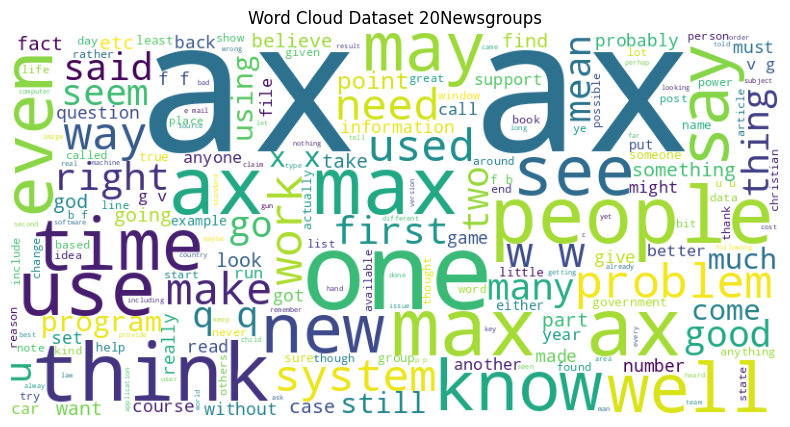

In [ ]:
# Visualisasi 1: Word Cloud
all_text = " ".join(clean_documents)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud Dataset 20Newsgroups")
plt.show()

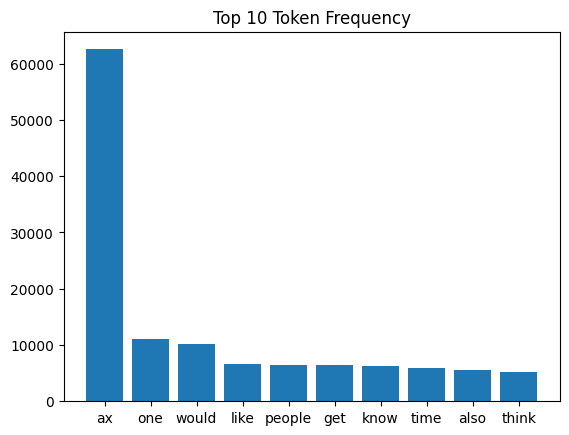

In [ ]:
# Visualisasi 2: Top 10 Kata Terbanyak
words = bow_vectorizer.get_feature_names_out()
word_counts = bow_matrix.sum(axis=0).A1
word_freq = dict(zip(words, word_counts))
sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:10]

plt.bar([x[0] for x in sorted_freq], [x[1] for x in sorted_freq])
plt.title("Top 10 Token Frequency")
plt.show()

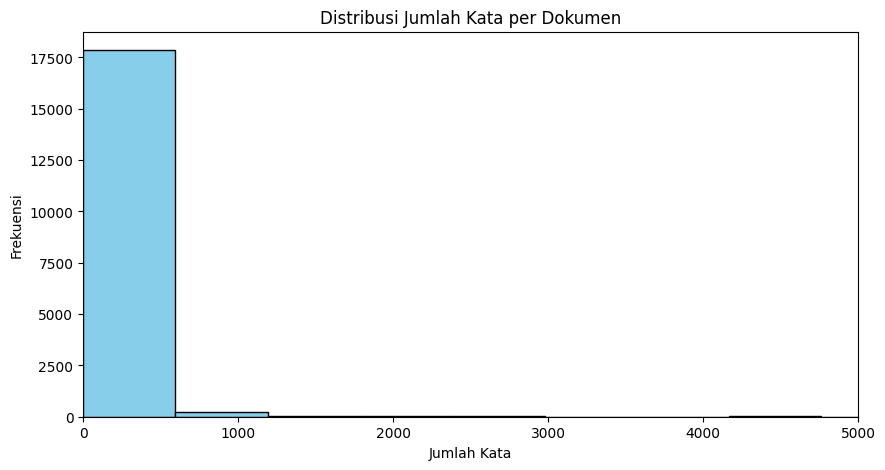

In [ ]:
# Visualisasi 3: Distribusi Panjang Dokumen
doc_lengths = [len(d.split()) for d in clean_documents]
plt.figure(figsize=(10, 5))
plt.hist(doc_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribusi Jumlah Kata per Dokumen")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.xlim(0, 5000)
plt.show()

In [ ]:
def search_document(query, vectorizer, matrix):
    query_clean = preprocess_text(query)
    query_vec = vectorizer.transform([query_clean])
    # Menghitung kemiripan vektor
    similarity = cosine_similarity(query_vec, matrix)
    index = np.argmax(similarity)
    score = np.max(similarity)
    return index, score

query_user = "space exploration and satellites"

# Uji Coba Perbandingan
idx_bow, score_bow = search_document(query_user, bow_vectorizer, bow_matrix)
idx_tfidf, score_tfidf = search_document(query_user, tfidf_vectorizer, tfidf_matrix)

print(f"Hasil BoW: Dokumen #{idx_bow} (Skor: {score_bow:.4f})")
print(f"Hasil TF-IDF: Dokumen #{idx_tfidf} (Skor: {score_tfidf:.4f})")

Hasil BoW: Dokumen #14640 (Skor: 0.5242)
Hasil TF-IDF: Dokumen #14640 (Skor: 0.4402)


In [ ]:
query_input = "space station and astronauts"

# Cari dengan BoW
idx_bow, score_bow = search_document(query_input, bow_vectorizer, bow_matrix)
# Cari dengan TF-IDF
idx_tfidf, score_tfidf = search_document(query_input, tfidf_vectorizer, tfidf_matrix)

print(f"QUERY: {query_input}")
print("-" * 30)
print(f"Hasil BoW (Top Match):\n{documents[idx_bow][:200]}...\nSkor: {score_bow:.4f}")
print("-" * 30)
print(f"Hasil TF-IDF (Top Match):\n{documents[idx_tfidf][:200]}...\nSkor: {score_tfidf:.4f}")

QUERY: space station and astronauts
------------------------------
Hasil BoW (Top Match):
The xgolf program was an April Fool's joke <sigh>....
Skor: 0.5055
------------------------------
Hasil TF-IDF (Top Match):



What _is_ your problem?  Hite's post wasn't a flame.  It was a
correction of *your* error.

YOUR reply was a flame.  


Not in the least.  

...
Skor: 0.4769
